**Food Recipes RAG Application**

This application is an automated Recipe RAG pipeline designed to parse recipe PDFs, split them into complete recipe chunks (keeping ingredients and steps unified), and store their vector representations in ChromaDB. Using Groq's high-throughput LLMs, users can ask natural language questions about dishes, ingredients, or preparation steps and receive grounded JSON responses. The pipeline integrates DeepEval to quantitatively score answer relevance, context retrieval quality, and factual accuracy.

**Sample View of Food Recipe PDF**

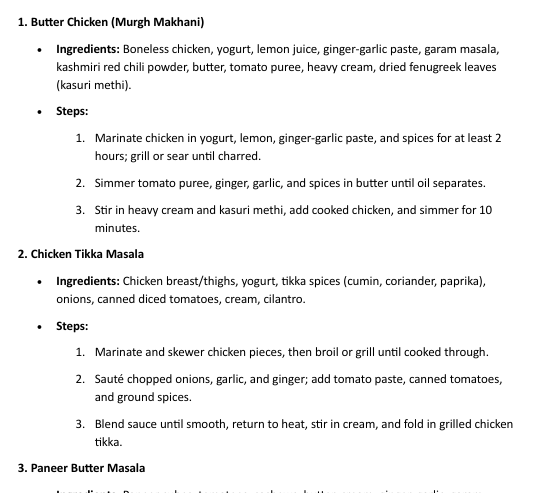

**Installing the Libraries**

In [3]:
!pip install -qU pypdf chromadb sentence-transformers groq deepeval | tail -n 1

**Dependency Import**

In [4]:
import re
import json
import os
from pypdf import PdfReader
import chromadb
from chromadb.utils import embedding_functions
from groq import Groq

**Reading the PDF**

In [6]:
# 1. Open and extract text from food-recipe.pdf
reader = PdfReader("food-recipe.pdf")
full_text = "\n".join([page.extract_text() for page in reader.pages if page.extract_text()])

**Creating Chunks From PDF**

Creating Chunks from the Food Recipe PDF such that recipe information remain in same chunk

In [7]:
# 2. Recipe-aware chunking based on entry numbers (e.g., "2. Chicken Tikka Masala")
def chunk_recipes(text):
    # Lookahead for: Line Start -> Digit(s). -> Title -> Newline -> Optional bullet/space -> Ingredients:
    recipe_pattern = r'(?=\n\d+\.\s+[A-Za-z0-9\s-]+\n\s*•?\s*Ingredients:)'

    text_to_split = "\n" + text.strip()

    chunks = [
        chunk.strip()
        for chunk in re.split(recipe_pattern, text_to_split, flags=re.MULTILINE | re.IGNORECASE)
        if chunk.strip()
    ]
    return chunks

chunks = chunk_recipes(full_text)
print(f"Extracted {len(chunks)} recipe chunk(s).")

Extracted 23 recipe chunk(s).


**Example chunk checked**

In [8]:
sample_text = """2. Chicken Tikka Masala
• Ingredients: Chicken breast/thighs, yogurt, tikka spices (cumin, coriander, paprika),
onions, canned diced tomatoes, cream, cilantro.
• Steps:
1. Marinate and skewer chicken pieces, then broil or grill until cooked through.
2. Sauté chopped onions, garlic, and ginger; add tomato paste, canned tomatoes,
and ground spices.
3. Blend sauce until smooth, return to heat, stir in cream, and fold in grilled chicken
tikka."""

chunks = chunk_recipes(sample_text)

print(f"Total chunks retrieved: {len(chunks)}")
print("--- Chunk Content ---")
print(chunks[0])

Total chunks retrieved: 1
--- Chunk Content ---
2. Chicken Tikka Masala
• Ingredients: Chicken breast/thighs, yogurt, tikka spices (cumin, coriander, paprika),
onions, canned diced tomatoes, cream, cilantro.
• Steps:
1. Marinate and skewer chicken pieces, then broil or grill until cooked through.
2. Sauté chopped onions, garlic, and ginger; add tomato paste, canned tomatoes,
and ground spices.
3. Blend sauce until smooth, return to heat, stir in cream, and fold in grilled chicken
tikka.


**Initialize Embedding**

In [9]:
st_embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Initialize Chromadb**

In [10]:
# 1. Initialize ChromaDB client and SentenceTransformer embedding function
chroma_client = chromadb.Client()

# 2. Create collection
collection = chroma_client.get_or_create_collection(
    name="food_recipes",
    embedding_function=st_embedding_function
)

**Saving chunks**

In [11]:

# 3. Add chunks to ChromaDB
documents = chunks
ids = [f"recipe_{i+1}" for i in range(len(chunks))]

collection.add(
    documents=documents,
    ids=ids
)
print("Recipes indexed successfully in ChromaDB.")

Recipes indexed successfully in ChromaDB.


**Initialize groq**

In [14]:
from google.colab import userdata
# 1. Set Groq API Key
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
groq_client = Groq()

**Used LLM to answer in structured JSON schema for user queries with retrieved recipe context.**

In [15]:
def query_recipe_rag(user_query: str):
    # Step A: Retrieve top relevant recipe chunk from ChromaDB
    results = collection.query(
        query_texts=[user_query],
        n_results=1
    )

    retrieved_chunk = results["documents"][0][0] if results["documents"] else ""

    # Step B: Construct Prompt forcing JSON output
    prompt = f"""
      You are a helpful culinary assistant.
      Answer the user's query using strictly the provided recipe context.

      Context:
      {retrieved_chunk}

      User Query:
      {user_query}

      Respond strictly in valid JSON format with the following keys:
      - "retrieved_chunk": (string) exact raw context retrieved
      - "answer": (string) clear and complete response addressing the query
      """

    # Step C: Generate JSON completion using Groq
    completion = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        response_format={"type": "json_object"}
    )

    # Step D: Parse and return JSON object
    return json.loads(completion.choices[0].message.content)

# Test the function
query = "How do I make the sauce for Chicken Tikka Masala?"
json_response = query_recipe_rag(query)

print(json.dumps(json_response, indent=2))

{
  "retrieved_chunk": "2. Chicken Tikka Masala\n\u2022 Ingredients: Chicken breast/thighs, yogurt, tikka spices (cumin, coriander, paprika),\nonions, canned diced tomatoes, cream, cilantro.\n\u2022 Steps:\n1. Marinate and skewer chicken pieces, then broil or grill until cooked through.\n2. Saut\u00e9 chopped onions, garlic, and ginger; add tomato paste, canned tomatoes,\nand ground spices.\n3. Blend sauce until smooth, return to heat, stir in cream, and fold in grilled chicken tikka.",
  "answer": "To make the sauce, first saut\u00e9 chopped onions, garlic, and ginger in a pan until softened. Add tomato paste, canned diced tomatoes, and the tikka spices (cumin, coriander, paprika). Cook briefly, then blend the mixture until smooth. Return the blended sauce to the heat, stir in cream, and keep it warm before folding in the grilled chicken tikka."
}


**Evaluate the response**

A RAG is evaluated as per three core pillars of RAG:

1. Retrieval Quality
2. Generation Quality
3. End-to-End Task Performance.

DeepEval achieves this by comparing four key components inside an LLMTestCase:


- input: The user's query.

- actual_output: The answer generated by your LLM/RAG app.

- retrieval_context: The text chunks retrieved from your vector database (e.g., ChromaDB).

- expected_output (optional): Ground-truth answer for comparison.

The RAG Evaluation Triad Metrics

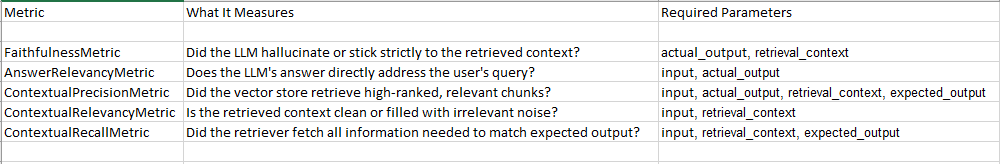

**Evaluating for FaithfulnessMetric, AnswerRelevancyMetric, ContextualPrecisionMetric**

In [16]:
import os
import json
import re
from pypdf import PdfReader
import chromadb
from chromadb.utils import embedding_functions
from groq import Groq

# DeepEval imports
from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualPrecisionMetric
)
from deepeval.models.base_model import DeepEvalBaseLLM

# --------------------------------------------------------------
# STEP 1: Define Groq LLM Wrapper for DeepEval
# --------------------------------------------------------------
class GroqLLM(DeepEvalBaseLLM):
    def __init__(self, model_name: str = "openai/gpt-oss-120b"):
        self.model_name = model_name
        self.client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

    def load_model(self):
        return self.client

    def generate(self, prompt: str) -> str:
        response = self.client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model=self.model_name,
            temperature=0.0,
        )
        return response.choices[0].message.content

    async def a_generate(self, prompt: str) -> str:
        return self.generate(prompt)

    def get_model_name(self) -> str:
        return self.model_name

# Initialize custom evaluator model
evaluator_llm = GroqLLM()

# --------------------------------------------------------------
# STEP 2: ChromaDB Setup & Recipe Chunking
# --------------------------------------------------------------
reader = PdfReader("food-recipe.pdf")
full_text = "\n".join([page.extract_text() for page in reader.pages if page.extract_text()])

def chunk_recipes(text):
    recipe_pattern = r'(?=\n\d+\.\s+[A-Za-z0-9\s-]+\n\s*•?\s*Ingredients:)'
    text_to_split = "\n" + text.strip()
    return [
        chunk.strip()
        for chunk in re.split(recipe_pattern, text_to_split, flags=re.MULTILINE | re.IGNORECASE)
        if chunk.strip()
    ]

chunks = chunk_recipes(full_text)

chroma_client = chromadb.Client()
st_embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

collection = chroma_client.get_or_create_collection(
    name="food_recipes",
    embedding_function=st_embedding_function
)

collection.add(
    documents=chunks,
    ids=[f"recipe_{i+1}" for i in range(len(chunks))]
)

# --------------------------------------------------------------
# STEP 3: Execute RAG Pipeline Query
# --------------------------------------------------------------
groq_client = Groq()

def query_recipe_rag(user_query: str):
    # Retrieve top chunk
    results = collection.query(query_texts=[user_query], n_results=1)
    retrieved_chunk = results["documents"][0][0] if results["documents"] else ""

    prompt = f"""
You are a helpful culinary assistant.
Answer the user's query using strictly the provided recipe context.

Context:
{retrieved_chunk}

User Query:
{user_query}

Respond strictly in valid JSON format with the following keys:
- "retrieved_chunk": (string) exact raw context retrieved
- "answer": (string) clear and complete response addressing the query
"""

    completion = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        response_format={"type": "json_object"}
    )

    parsed_response = json.loads(completion.choices[0].message.content)
    return parsed_response, retrieved_chunk

# Execute query
user_query = "How do I make the sauce for Chicken Tikka Masala?"
rag_output, retrieved_chunk = query_recipe_rag(user_query)

# --------------------------------------------------------------
# STEP 4: DeepEval Test Case & Metric Evaluation
# --------------------------------------------------------------
# Construct LLMTestCase
test_case = LLMTestCase(
    input=user_query,
    actual_output=rag_output["answer"],
    retrieval_context=[retrieved_chunk],
    expected_output="To make the sauce, first blend the sauce ingredients until they are completely smooth. Return the blended sauce to the pan and heat it gently. Once hot, stir in the cream to create a rich, velvety base. Finally, fold in the grilled chicken tikka pieces, allowing them to coat in the sauce before serving." # Added this field
)

# Instantiate Metrics using Groq
faithfulness = FaithfulnessMetric(threshold=0.7, model=evaluator_llm)
answer_relevancy = AnswerRelevancyMetric(threshold=0.7, model=evaluator_llm)
context_precision = ContextualPrecisionMetric(threshold=0.7, model=evaluator_llm)

# Run evaluation
results = evaluate(
    test_cases=[test_case],
    metrics=[faithfulness, answer_relevancy, context_precision]
)

✨ You're running DeepEval's latest Faithfulness Metric! (using openai/gpt-oss-120b, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using openai/gpt-oss-120b, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using openai/gpt-oss-120b, strict=False, 
async_mode=True)...

Output()

INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ✅ test_case_0 (Passed 3 metrics)                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Aggregate Metrics                                                                                               │
│                                                                                                                 │
│  Metric                         ┃ Average Score        ┃ Pass Rate                                   ┃ Total    │
│ ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━ │
│  Faithfulness                   │ 1.00                 │ 100.00% | passed=1 | failed=0               │ 1        │
│  Answer Relevancy               │ 1.00                 │ 100.00% | passed=1 | failed=0               │ 1        │
│  Contextual Precision           │ 1.00                 │ 100.00% | passed=1 | failed=0               │ 1        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

⚠ WARNING: No hyperparameters logged.
» ]8;id=502112;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 10.13s | token cost: None)
» Test Results (1 total tests):
   » Pass Rate: 100.0% | Passed: 1 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.